# MAE 223 — Tutorial: Spectral Analysis

This tutorial explores how chunk size (number of segments) affects spectral resolution and stability in Welch's method. You will experiment with the La Jolla tide gauge data.

Work through the exercises in order. Cells marked `# YOUR CODE HERE` require you to write code. Reflection questions should be answered in the provided markdown cells.

The `spectrumCB` function is defined in the cell directly below — run it first before proceeding.

In [1]:
import numpy as np
from scipy.signal import detrend as scipy_detrend


def spectrumCB(time, data, chunk):
    """
    Compute a one-sided Power Spectral Density (PSD) using Welch's method:
    50% overlapping segments, linear detrending, FFT, and ensemble averaging.

    Parameters
    ----------
    time  : array-like
        Time vector in decimal days. Used only to compute mean sample interval.
    data  : array-like
        Data values. Must be NaN-free before calling.
    chunk : int
        Number of samples per segment. Larger chunk -> finer frequency
        resolution but fewer segments and a noisier estimate.

    Returns
    -------
    f        : ndarray  — one-sided frequency vector [cpd]
    a        : ndarray  — averaged PSD [units² / cpd]
    parseval : float    — ratio ∫PSD df / var(data); should be ≈ 1.0
    """
    data  = np.asarray(data,  dtype=float)
    time  = np.asarray(time,  dtype=float)
    chunk = int(chunk)

    # --- split into 50% overlapping segments ---
    segments = []
    step = chunk // 2
    ind  = 0
    while ind + chunk <= len(data):
        segments.append(data[ind : ind + chunk])
        ind += step

    # --- frequency vector ---
    dt = np.nanmean(np.diff(time))       # mean sample interval [days]
    fn = 1.0 / (2.0 * dt)               # Nyquist frequency [cpd]
    N  = chunk
    T  = dt * N                          # segment length [days]
    df = 1.0 / T                         # frequency resolution [cpd]
    f  = np.arange(0, fn + df / 2, df)  # one-sided frequency vector
    nf = len(f)

    # --- compute and average PSD across segments ---
    A = np.empty((len(segments), nf))
    for i, seg in enumerate(segments):
        seg_dt   = scipy_detrend(seg)            # remove linear trend
        fft_vals = np.fft.fft(seg_dt)            # full FFT
        amp = np.abs(fft_vals[:nf]) ** 2         # one-sided amplitude²
        amp = amp / N ** 2                       # normalize DFT output
        amp = amp * 2                            # fold negative frequencies
        amp = amp / df                           # convert to density [units²/cpd]
        A[i] = amp
    a = A.mean(axis=0)

    # --- Parseval check ---
    variance = np.nanstd(data) ** 2
    int_spec  = np.trapezoid(a, f)
    parseval  = int_spec / variance

    print(f"  Segments used:  {len(segments)}")
    print(f"  Parseval check: {parseval:.4f}  (ideal = 1.00)")
    return f, a, parseval


---
# Part 1 — Understanding Spectral Resolution

## Purpose

When you call `spectrumCB(time, data, chunk)`, the `chunk` argument controls how many samples go into each segment of Welch's method. This single parameter determines a fundamental tradeoff in spectral estimation — and understanding it is essential for interpreting any spectrum you compute.

In this part, you will:
1. Load the familiar La Jolla tide gauge record
2. Compute spectra using four different chunk sizes
3. Plot them side by side and observe how the spectra change
4. Answer reflection questions that build physical intuition about the tradeoff

## Background: The Resolution–Stability Tradeoff

Welch's method divides your time series into overlapping **segments**, computes a periodogram for each, and averages them together. The length of each segment — the chunk size — controls two competing properties of the resulting spectrum.

### Frequency resolution

The **frequency resolution** `df` is the smallest frequency difference the spectrum can distinguish:

$$\Delta f = \frac{1}{T_{\text{segment}}} = \frac{1}{\text{chunk} \times dt}$$

where `dt` is the sample interval in days. A **longer segment** gives **finer frequency resolution** — the spectral peaks are sharper and you can distinguish constituents that are close together in frequency (like M₂ and S₂, which are only ~0.07 cpd apart).

### Spectral stability

**Spectral stability** (or smoothness) comes from averaging many independent segment estimates. More segments means more averaging, which reduces the noise-like fluctuations in the spectrum. But — here is the tradeoff — **more segments means shorter segments**, which means **coarser frequency resolution**.

### Intuition

Think of it like a photograph:
- **Long segments (few chunks):** High-resolution image, but grainy because you only have a few exposures to average. Peaks are sharp, but the background is noisy.
- **Short segments (many chunks):** Smooth image from many exposures, but the fine detail is blurred. Peaks are broad and may merge together.

There is no universally "correct" choice — it depends on what you are trying to resolve. For tidal analysis, you need fine enough resolution to separate individual tidal constituents. For a broad overview of energy distribution, more smoothing is fine.

| Setting | Chunk size | Segment length | df | Stability |
|---------|-----------|---------------|-----|----------|
| Very few chunks | Large | Long | Fine | Low (noisy) |
| Many chunks | Small | Short | Coarse | High (smooth) |

In [2]:
import json
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime

# =============================================================================
# Load the La Jolla NOAA tide gauge record
# =============================================================================
# la_jolla_tide.json contains the full ~100-year NOAA record (1925–2025),
# sampled hourly. Sea level is in millimetres relative to a fixed datum.
# Missing observations are stored as JSON null (Python reads these as None).

with open('la_jolla_tide.json') as f:
    lj = json.load(f)

# Replace None (JSON null) with np.nan so NumPy can handle missing values.
sea_level_raw = np.array(
    [np.nan if v is None else v for v in lj['sea_level']]
)  # [mm]

# -------------------------------------------------------------------------
# Convert ISO timestamp strings to decimal days since the record start
# -------------------------------------------------------------------------
# spectrumCB uses the time vector only to compute dt (mean sample interval).
# We express time in days: parse each string -> timedelta -> total seconds / 86400.
t_parsed = [datetime.strptime(s, '%Y-%m-%dT%H:%M') for s in lj['time']]
t0       = t_parsed[0]                         # reference epoch (record start)
time_lj  = np.array(
    [(t - t0).total_seconds() / 86400.0 for t in t_parsed]
)  # [decimal days since 1925-01-01]

dt_lj = np.nanmean(np.diff(time_lj))           # mean sample interval [days] ≈ 1/24

# -------------------------------------------------------------------------
# Linearly interpolate across missing values (NaNs)
# -------------------------------------------------------------------------
# spectrumCB requires a NaN-free input. np.interp evaluates a piecewise
# linear interpolant at all time points, using only the valid (non-NaN) data.
nan_mask         = np.isnan(sea_level_raw)
sea_level_interp = np.interp(
    time_lj,               # evaluate at all times (including gaps)
    time_lj[~nan_mask],    # times with valid observations
    sea_level_raw[~nan_mask]  # corresponding valid sea-level values
)

print(f"Record:  {lj['metadata']['start']}  ->  {lj['metadata']['end']}")
print(f"Samples: {len(sea_level_interp):,}  |  Missing filled: {nan_mask.sum():,}")
print(f"dt:      {dt_lj * 24:.4f} hours")

Record:  1925-01-01T00:00  ->  2025-02-28T22:59
Samples: 878,016  |  Missing filled: 48,512
dt:      1.0000 hours


## Exercise 1 — Compare Four Chunk Sizes

Below is a loop that computes the PSD of the La Jolla tide gauge record using different chunk sizes. The structure is given — your job is to fill in the list of chunk counts to try and the corresponding labels.

**Instructions:**
1. Choose four values for `num_chunks_list` — the number of segments to divide the record into. Try a wide range (e.g., from very few segments to many). Suggested values: `[2, 5, 10, 40]`.
2. Fill in a matching `labels` list with descriptive strings for the legend (e.g., `'2 chunks'`).
3. Run the cell. The Parseval output will confirm the normalization is correct for each run.

The plotting cell after this one will overlay all four spectra automatically.

In [3]:
# =============================================================================
# Exercise 1: Choose chunk sizes to compare
# =============================================================================

# YOUR CODE HERE — fill in the list of number-of-chunks values to try.
# These integers control how many equal segments the record is divided into.
# Try a wide range so the tradeoff is clearly visible in the plot.
num_chunks_list = [2, 5, 10, 40]   # YOUR CODE HERE: e.g. [2, 5, 10, 40]

# YOUR CODE HERE — fill in a label for each entry above.
# These strings will appear in the plot legend.
labels = ['2 chunks', '5 chunks', '10 chunks', '40 chunks']   # YOUR CODE HERE

# -------------------------------------------------------------------------
# Loop: compute PSD for each chunk setting
# -------------------------------------------------------------------------
# We store the results in a list of tuples so the plotting cell can access them.
results = []   # will hold (f, psd, label) for each run

for n_chunks, label in zip(num_chunks_list, labels):
    chunk_size = len(sea_level_interp) // n_chunks   # samples per segment
    seg_len_days = chunk_size * dt_lj                 # segment length [days]
    df = 1.0 / seg_len_days                           # frequency resolution [cpd]

    print(f"--- {label}: chunk = {chunk_size:,} samples  |  "
          f"T_seg = {seg_len_days:.1f} days  |  df = {df:.4f} cpd")

    f_out, psd_out, _ = spectrumCB(time_lj, sea_level_interp, chunk_size)
    results.append((f_out, psd_out, label))
    print()

--- 2 chunks: chunk = 439,008 samples  |  T_seg = 18292.0 days  |  df = 0.0001 cpd
  Segments used:  3
  Parseval check: 0.9851  (ideal = 1.00)

--- 5 chunks: chunk = 175,603 samples  |  T_seg = 7316.8 days  |  df = 0.0001 cpd
  Segments used:  9
  Parseval check: 0.9811  (ideal = 1.00)

--- 10 chunks: chunk = 87,801 samples  |  T_seg = 3658.4 days  |  df = 0.0003 cpd
  Segments used:  19
  Parseval check: 0.9812  (ideal = 1.00)

--- 40 chunks: chunk = 21,950 samples  |  T_seg = 914.6 days  |  df = 0.0011 cpd
  Segments used:  79
  Parseval check: 0.9779  (ideal = 1.00)



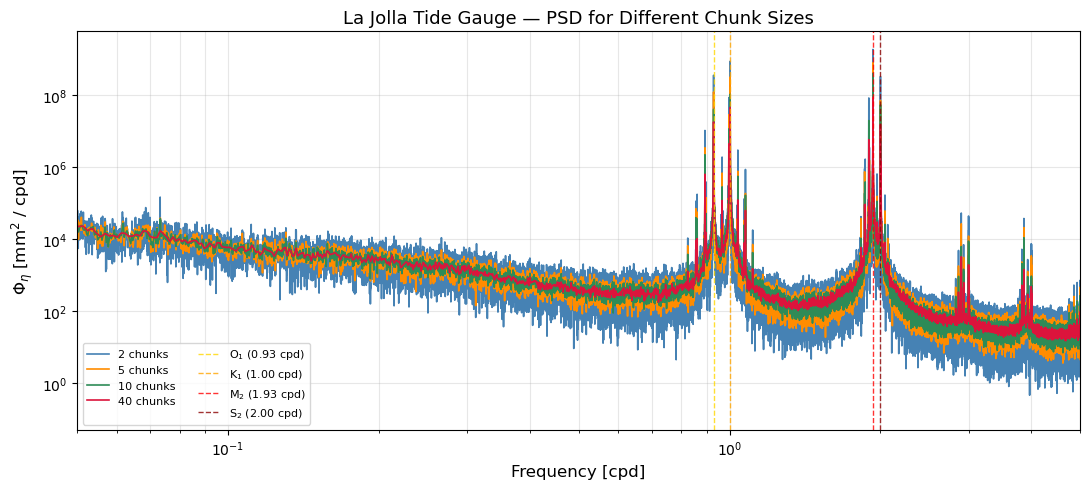

In [4]:
# =============================================================================
# Plot all four PSDs overlaid on a single log-log axes
# =============================================================================
# Using a colormap so each chunk setting gets a distinct, visually clear color.
colors = ['steelblue', 'darkorange', 'seagreen', 'crimson']

fig, ax = plt.subplots(figsize=(11, 5))

for (f_r, psd_r, lbl), color in zip(results, colors):
    # Skip index 0 (zero-frequency DC bin) to avoid log(0) on the x-axis
    ax.loglog(f_r[1:], psd_r[1:], lw=1.2, color=color, label=lbl)

# -------------------------------------------------------------------------
# Tidal constituent reference lines
# -------------------------------------------------------------------------
# Vertical dashed lines mark known tidal frequencies so you can judge
# how well each chunk setting resolves the individual peaks.
#
#   O₁  — principal lunar diurnal        period = 25.82 h  (~0.93 cpd)
#   K₁  — lunisolar diurnal              period = 23.93 h  (1.00 cpd)
#   M₂  — principal lunar semidiurnal    period = 12.42 h  (~1.93 cpd)
#   S₂  — principal solar semidiurnal    period = 12.00 h  (2.00 cpd)
tidal_lines = [
    (24 / 25.82,  'O$_1$ (0.93 cpd)',  'gold'),
    (1.0,         'K$_1$ (1.00 cpd)',  'orange'),
    (24 / 12.42,  'M$_2$ (1.93 cpd)', 'red'),
    (24 / 12.00,  'S$_2$ (2.00 cpd)', 'darkred'),
]
for freq, lbl, clr in tidal_lines:
    ax.axvline(freq, color=clr, ls='--', lw=1.0, alpha=0.8, label=lbl)

# Axis formatting
ax.set_xlabel('Frequency [cpd]', fontsize=12)
ax.set_ylabel(r'$\Phi_\eta$ [mm$^2$ / cpd]', fontsize=12)
ax.set_title('La Jolla Tide Gauge — PSD for Different Chunk Sizes', fontsize=13)
ax.set_xlim([0.05, 5])                      # focus on tidal frequency band
ax.legend(fontsize=8, loc='lower left', ncol=2)
ax.grid(True, which='both', alpha=0.3)      # grid on both major and minor log ticks
plt.tight_layout()
plt.show()

## Reflection Questions — Part 1

Answer all three questions in the markdown cell below. Show any calculations inline.

---

**Q1.** Which chunk setting gives the sharpest tidal peaks (e.g., at M₂ and S₂)? Why does a larger chunk size produce sharper peaks? Refer to the formula for `df` in your answer.

--- 

**Q2.** Which chunk setting gives the smoothest spectral curve (least jagged background)? What is the tradeoff you accept when you choose many short segments? Is this tradeoff acceptable for tidal analysis?

---

**Q3.** M₂ (1.932 cpd) and S₂ (2.000 cpd) are separated by approximately **0.068 cpd**. To resolve them as distinct peaks, the frequency resolution must satisfy `df < 0.068 cpd`.

  a. Using `df = 1 / T_segment`, calculate the **minimum segment length** (in days) needed to resolve M₂ from S₂.

  b. The La Jolla record is sampled hourly (dt = 1/24 day). How many samples must each segment contain?

  c. With 878,016 total hourly samples, what is the **maximum number of non-overlapping segments** you could use while still meeting this resolution requirement? (Hint: `n_chunks = N_total / chunk_size`)

**Your answers:**

Q1: The chunk size of 2 gives the sharpest tidal peaks. This is because df is the inverse of the mean number sampling period, here is a day, times the chunk length. Here, a larger chunk size would result in higher frequency resolution. As such, peaks become distributed across multiple frequencies as compared to a greater df where peaks would be concentrated to a frequency.

Q2: The largest chunk size of 40 chunks gives the smoothest spectral curve. The tradeoff when using a high number of short segments is reducing noise-like fluctuations. However, increasing the amount of segments lowers the ability to distinguish between closely spaced frequncies with peaks becoming broad, leading to a less precise frequency spectrum. For tidal analysis, this may be acceptable as long as the peaks are distinguishable. A lower chunk size would likely make the peaks more apparaent.

Q3a: T_segment = 1/df. As M2 and S2 are separated by approximately 0.068 cpd where df must be greater, T_segment > 1/0.068 = 14.71 days

Q3b: As dt = 1/24 day and T_segment is at least 14.71 days, each sample must contain at least N = T_segment/dt = 353 samples. 

Q3c: With 878016 total samples and each with a chunk size of 353 samples, n chunks is the floor of their quotient, becoming 2487 chunks.